<a href="https://colab.research.google.com/github/agtorres1/DDS_tp_anual/blob/main/notebooks/01_mlp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Descarga del dataset

Instalamos la librería de Kaggle y descargamos el Credit Card Fraud Detection Dataset.

In [6]:
from google.colab import userdata
import os
os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN')

In [7]:
!pip install kaggle
!kaggle datasets download -d mlg-ulb/creditcardfraud
!unzip -o creditcardfraud.zip

Dataset URL: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
License(s): DbCL-1.0
creditcardfraud.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  creditcardfraud.zip
  inflating: creditcard.csv          


## 2. Carga y preprocesamiento de datos

Cargamos el CSV, escalamos las columnas Time y Amount con StandardScaler,
separamos las características (X) del target (y), y hacemos el split
train/test manteniendo la proporción de clases con stratify.

In [8]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

df = pd.read_csv('creditcard.csv')

scaler = StandardScaler()
df['Time'] = scaler.fit_transform(df[['Time']])
df['Amount'] = scaler.fit_transform(df[['Amount']])

X = df.drop(columns=['Class'])
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (227845, 30) Test: (56962, 30)


## 3. Arquitectura del MLP

Definimos un Perceptrón Multicapa (MLP) feedforward:
- Capa de entrada: 30 características
- Dos capas ocultas (32 y 16 neuronas) con activación ReLU
- Dropout del 30% en cada capa oculta para evitar overfitting
- Capa de salida con activación sigmoide, que devuelve la probabilidad de fraude

In [9]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(16, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,537 (6.00 KB)

 Trainable params: 1,537 (6.00 KB)

 Non-trainable params: 0 (0.00 B)

## 4. Compilación del modelo

Configuramos cómo va a aprender la red:
- Optimizador Adam (ajusta los pesos con Backpropagation)
- Función de pérdida binary_crossentropy (para clasificación binaria)
- Métricas de seguimiento: accuracy, Precision y Recall

In [10]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.Precision(name='precision'), keras.metrics.Recall(name='recall')]
)

## 5. Pesos de clase para el desbalance

Calculamos un peso mayor para la clase minoritaria (fraude), para que el
modelo penalice más fuerte los errores en esa clase durante el entrenamiento.

In [11]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

pesos = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train.values
)
class_weight_dict = dict(enumerate(pesos))
print(class_weight_dict)

{0: np.float64(0.5008661206149896), 1: np.float64(289.14340101522845)}


## 6. Entrenamiento del modelo

Entrenamos el MLP durante 20 épocas, usando los pesos de clase calculados
y reservando un 20% del set de entrenamiento para validación en cada época.

In [12]:
historia = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=256,
    validation_split=0.2,
    class_weight=class_weight_dict
)

Epoch 1/20
713/713 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8874 - loss: 0.4462 - precision: 0.0121 - recall: 0.8071 - val_accuracy: 0.9805 - val_loss: 0.1990 - val_precision: 0.0786 - val_recall: 0.9036
Epoch 2/20
713/713 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9520 - loss: 0.2502 - precision: 0.0304 - recall: 0.8778 - val_accuracy: 0.9806 - val_loss: 0.1470 - val_precision: 0.0796 - val_recall: 0.9157
Epoch 3/20
713/713 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9662 - loss: 0.1952 - precision: 0.0433 - recall: 0.8907 - val_accuracy: 0.9772 - val_loss: 0.1288 - val_precision: 0.0687 - val_recall: 0.9157
Epoch 4/20
713/713 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9655 - loss: 0.1819 - precision: 0.0424 - recall: 0.8907 - val_accuracy: 0.9761 - val_loss: 0.1103 - val_precision: 0.0657 - val_recall: 0.9157
Epoch 5/20
713/713 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9615 - loss: 0.1835 - precision: 0.0383 - recall: 0.8939 - val_accuracy: 0.9752 - val_loss: 0.

## 7. Evaluación sobre el conjunto de test

Medimos el desempeño del modelo con las métricas clave para clasificación
desbalanceada: Precision, Recall, F1-Score, ROC-AUC y PR-AUC, además de
la matriz de confusión.

In [15]:
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix
)
import pandas as pd

y_proba = model.predict(X_test)
y_pred = (y_proba > 0.5).astype(int)

metricas = pd.DataFrame({
    "Métrica": ["Precision", "Recall", "F1-Score", "ROC-AUC", "PR-AUC"],
    "Valor": [
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        roc_auc_score(y_test, y_proba),
        average_precision_score(y_test, y_proba)
    ]
})

metricas["Valor"] = metricas["Valor"].round(4)

# Formato visual: barras de color proporcionales al valor
metricas.style.bar(subset=["Valor"], color="#5DCAA5", vmin=0, vmax=1).format({"Valor": "{:.4f}"})

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step


,Métrica,Valor
0,Precision,0.0874
1,Recall,0.8980
2,F1-Score,0.1593
3,ROC-AUC,0.9750
4,PR-AUC,0.7180


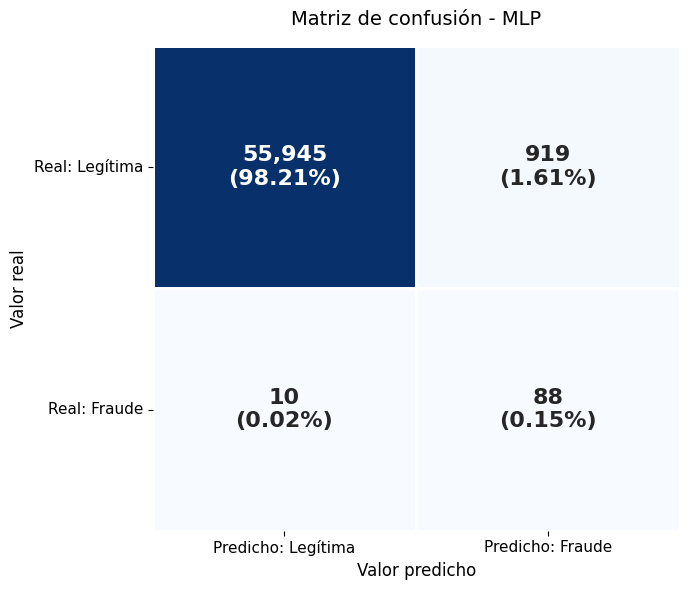

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

matriz = confusion_matrix(y_test, y_pred)

# Armamos etiquetas que muestran cantidad Y porcentaje en cada celda
total = matriz.sum()
etiquetas = np.array([
    f"{valor:,}\n({valor/total*100:.2f}%)" for valor in matriz.flatten()
]).reshape(2, 2)

plt.figure(figsize=(7, 6))
sns.heatmap(
    matriz,
    annot=etiquetas,
    fmt='',
    cmap='Blues',
    xticklabels=['Predicho: Legítima', 'Predicho: Fraude'],
    yticklabels=['Real: Legítima', 'Real: Fraude'],
    annot_kws={"size": 16, "weight": "bold"},
    cbar=False,
    linewidths=2,
    linecolor='white'
)
plt.title('Matriz de confusión - MLP', fontsize=14, pad=15)
plt.ylabel('Valor real', fontsize=12)
plt.xlabel('Valor predicho', fontsize=12)
plt.yticks(rotation=0, fontsize=11)
plt.xticks(fontsize=11)
plt.tight_layout()
plt.show()

## 8. Comparación de distintos umbrales de decisión

Probamos varios puntos de corte para clasificar una transacción como
fraude, y comparamos cómo cambian Precision, Recall y F1-Score en cada caso.

In [18]:
umbrales = [0.1, 0.3, 0.5, 0.7, 0.9]
resultados = []

for u in umbrales:
    y_pred_u = (y_proba > u).astype(int)
    resultados.append({
        "Umbral": u,
        "Precision": precision_score(y_test, y_pred_u),
        "Recall": recall_score(y_test, y_pred_u),
        "F1-Score": f1_score(y_test, y_pred_u),
        "Falsos Positivos": confusion_matrix(y_test, y_pred_u)[0][1],
        "Falsos Negativos": confusion_matrix(y_test, y_pred_u)[1][0]
    })

tabla_umbrales = pd.DataFrame(resultados).round(4)
tabla_umbrales

,Umbral,Precision,Recall,F1-Score,Falsos Positivos,Falsos Negativos
0,0.1,0.0214,0.9286,0.0417,4171,7
1,0.3,0.0493,0.9082,0.0935,1717,9
2,0.5,0.0874,0.8980,0.1593,919,10
3,0.7,0.1956,0.8980,0.3212,362,10
4,0.9,0.4038,0.8776,0.5531,127,12
